## Created by:
- Mikołaj Nowak 151813
- Igor Szymczak 160280

Try to improve the movie recommendation system, you can use the following ideas:
 - Can we use more users (e.g. with negative correlation)?
 - Which difference is more important predicting 5 when a real score is 4 or predicting 3 instead of 2?
 - Did we use the best value for the minimal number of common movies?
 - Is prediction for a movie seen by just one user trustworthy?
 
 
Describe your approach, its strengths and weaknesses, and analyze the results. Send the report (notebook with comments/markdown) within 144 hours after the class to gmiebs@cs.put.poznan.pl, start the subject with [IR]

In [1]:
import warnings
import numpy as np

# Suppress all RuntimeWarnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

## 1. Data Preprocessing

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr

df = pd.read_csv('./ratings.csv')

In [3]:
ratings_matrix = df.pivot(index='movieId', columns='userId', values='rating')

## 2. Initial Benchmark for One User

Let's evaluate the baseline performance of our recommendation system using a single target user. 

The function `evaluate_recommendations` hides a few randomly selected movies that the user has rated and predicts their scores based on the ratings from other users. Predictions are computed as a weighted average, where the weights are the Pearson correlation coefficients between the target user and all other users.

The evaluation reports:
- The hidden movies and their actual ratings
- Predicted ratings for these movies
- Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE)
- A scatter plot comparing predicted vs actual ratings, with a red dashed line representing perfect predictions (`y=x`).

This benchmark provides a reference point for later improvements and experiments.


In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

def evaluate_recommendations(ratings_matrix, user_id, n_hidden=5, random_state=42, plot=True):
    np.random.seed(random_state)
    target_ratings = ratings_matrix[user_id].copy()

    rated_movies = target_ratings.dropna().index
    if len(rated_movies) < n_hidden:
        n_hidden = len(rated_movies)
    hidden_movies = np.random.choice(rated_movies, size=n_hidden, replace=False)
    hidden_ratings = target_ratings[hidden_movies].copy()
    ratings_matrix.loc[hidden_movies, user_id] = np.nan

    target = ratings_matrix[user_id]
    similarities = ratings_matrix.corrwith(target).drop(user_id)

    predicted_scores = {}
    for movie in ratings_matrix.index:
        users_who_rated = ratings_matrix.loc[movie].dropna().index
        relevant_users = users_who_rated.intersection(similarities.index)
        if len(relevant_users) < 2:
            continue

        weights = similarities[relevant_users]
        ratings = ratings_matrix.loc[movie, relevant_users].copy()

        # Only keep valid ratings
        mask = ratings.notna()
        ratings = ratings[mask]
        weights = weights[mask]

        # Handle negative correlations
        negative_mask = weights < 0
        ratings[negative_mask] = 5.5 - ratings[negative_mask]

        # Clip ratings and take absolute weights
        ratings = ratings.clip(0.5, 5)
        weights = weights.abs()

        denom = np.sum(weights)
        if denom == 0:
            continue

        pred = np.sum(weights * ratings) / denom
        predicted_scores[movie] = np.clip(pred, 0, 5)

    predicted_scores = pd.Series(predicted_scores)
    hidden_predicted = [m for m in hidden_movies if m in predicted_scores.index]
    if not hidden_predicted:
        ratings_matrix.loc[hidden_movies, user_id] = target_ratings[hidden_movies]
        return None, None

    predicted_hidden = predicted_scores[hidden_predicted]
    actual_hidden = hidden_ratings[hidden_predicted]

    mae = mean_absolute_error(actual_hidden, predicted_hidden)
    rmse = np.sqrt(mean_squared_error(actual_hidden, predicted_hidden))

    if plot:
        plt.figure(figsize=(6, 6))
        plt.scatter(actual_hidden, predicted_hidden, color='blue', label='Predicted vs Actual')
        plt.plot([0, 5], [0, 5], 'r--', label='Perfect Prediction (y=x)')
        plt.xlabel("Actual Ratings")
        plt.ylabel("Predicted Ratings")
        plt.title(f"User {user_id} - Predicted vs Actual Ratings")
        plt.xlim(0, 5)
        plt.ylim(0, 5)
        plt.grid(True)
        plt.legend()
        plt.show()

    ratings_matrix.loc[hidden_movies, user_id] = target_ratings[hidden_movies]
    return mae, rmse

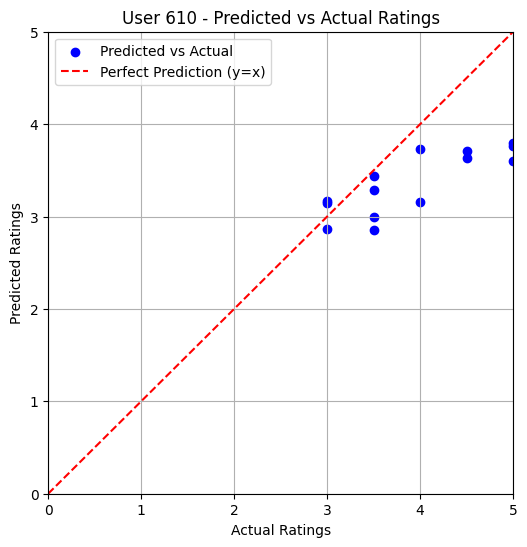

(0.6071433627773725, np.float64(0.7515567414717783))

In [5]:
evaluate_recommendations(ratings_matrix, user_id=610, n_hidden=20, plot=True)

Let's evaluate the overall performance of our recommendation system across all users.

The function `evaluate_all_users` hides a few randomly selected movies that each user has rated and predicts their scores based on the ratings from other users. Predictions are computed as a weighted average, where the weights are the Pearson correlation coefficients between the target user and all other users. User-user correlations are precomputed to speed up the process.

The evaluation reports:
- Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) for each user
- Overall MAE and RMSE averaged across all users
- Distributions of MAE and RMSE across users, providing insight into how prediction accuracy varies within the dataset

This benchmark provides a reference point for assessing the recommendation system’s performance and for guiding future improvements.

In [6]:
def evaluate_all_users(ratings_matrix, n_hidden=5, random_state=42, plot=False):
    np.random.seed(random_state)
    users = ratings_matrix.columns
    maes = []
    rmses = []

    # Precompute user-user correlations
    user_corr = ratings_matrix.corr()

    for i, user_id in enumerate(users, 1):
        target_ratings = ratings_matrix[user_id].copy()
        rated_movies = target_ratings.dropna().index
        if len(rated_movies) == 0:
            continue

        nh = min(n_hidden, len(rated_movies))
        hidden_movies = np.random.choice(rated_movies, size=nh, replace=False)
        hidden_ratings = target_ratings[hidden_movies].copy()
        ratings_matrix.loc[hidden_movies, user_id] = np.nan

        similarities = user_corr[user_id].drop(user_id)
        predicted_scores = {}

        for movie in ratings_matrix.index:
            users_who_rated = ratings_matrix.loc[movie].dropna().index
            relevant_users = users_who_rated.intersection(similarities.index)
            if len(relevant_users) < 2:
                continue

            weights = similarities[relevant_users]
            ratings = ratings_matrix.loc[movie, relevant_users].copy()

            # Only keep valid ratings
            mask = ratings.notna()
            ratings = ratings[mask]
            weights = weights[mask]

            # Handle negative correlations
            negative_mask = weights < 0
            ratings[negative_mask] = 5.5 - ratings[negative_mask]

            # Clip ratings and take absolute weights
            ratings = ratings.clip(0.5, 5)
            weights = weights.abs()

            denom = np.sum(weights)
            if denom == 0:
                continue

            pred = np.sum(weights * ratings) / denom
            predicted_scores[movie] = np.clip(pred, 0.5, 5)

        predicted_scores = pd.Series(predicted_scores)
        hidden_predicted = [m for m in hidden_movies if m in predicted_scores.index]
        if not hidden_predicted:
            ratings_matrix.loc[hidden_movies, user_id] = target_ratings[hidden_movies]
            continue

        predicted_hidden = predicted_scores[hidden_predicted]
        actual_hidden = hidden_ratings[hidden_predicted]

        maes.append(mean_absolute_error(actual_hidden, predicted_hidden))
        rmses.append(np.sqrt(mean_squared_error(actual_hidden, predicted_hidden)))

        ratings_matrix.loc[hidden_movies, user_id] = target_ratings[hidden_movies]

    maes = np.array(maes)
    rmses = np.array(rmses)

    if plot:
        print(f"Overall MAE: {maes.mean():.3f} ± {maes.std():.3f}")
        print(f"Overall RMSE: {rmses.mean():.3f} ± {rmses.std():.3f}")

        plt.figure(figsize=(10,4))
        plt.subplot(1,2,1)
        plt.hist(np.clip(maes, 0.5, 5), bins=50, color='skyblue', edgecolor='black')
        plt.xlabel("MAE")
        plt.ylabel("Frequency")
        plt.title("Distribution of MAE across all users")

        plt.subplot(1,2,2)
        plt.hist(np.clip(rmses, 0.5, 5), bins=50, color='salmon', edgecolor='black')
        plt.xlabel("RMSE")
        plt.ylabel("Frequency")
        plt.title("Distribution of RMSE across all users")

        plt.tight_layout()
        plt.show()

    return pd.DataFrame({'MAE': maes, 'RMSE': rmses})

Overall MAE: 0.882 ± 0.374
Overall RMSE: 0.993 ± 0.383


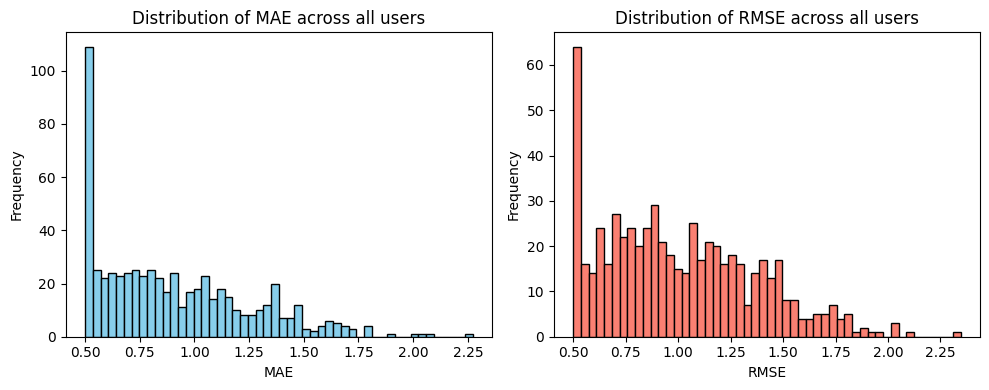

In [7]:
basic_results_df = evaluate_all_users(ratings_matrix, n_hidden=5, plot=True)

## 3. Improved User-Based Recommendation Evaluation

The improved evaluation function improves prediction accuracy using several key ideas:

- **Mean-centered user profiles**  
  Each user's ratings are centered by subtracting their own mean rating. Predictions are computed relative to each user's average behavior rather than raw ratings. This helps account for users who rate consistently high or low.

- **Weighted predictions using correlations**  
  Ratings from other users are combined using Pearson correlation coefficients as weights. Strongly correlated users have more influence on the predicted score.

- **Handling negative correlations**  
  If a user is negatively correlated with the target user, their deviation from their own mean is **negated**.  
  - Positive deviation → decreases prediction for target user  
  - Negative deviation → increases prediction for target user  
  This allows the model to account for "opposite taste" relationships.

- **Thresholding small correlations**  
  Correlations close to zero are ignored to reduce noise from weakly related users.

- **Optional squaring of correlations**  
  Squaring the correlation weights emphasizes the contribution of strongly correlated users and further reduces the influence of moderate correlations.

These design choices make the model more robust to user bias, exploit the signal from negatively correlated users, and emphasize the most relevant similarities when predicting missing ratings.


In [8]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

def evaluate_all_users_advanced(ratings_matrix, n_hidden=5, random_state=42, plot=False,
                                corr_threshold=0.1, use_negatives=True):
    """
    Advanced evaluation for all users with NaN-safe weights and debug stats.
    """
    np.random.seed(random_state)
    users = ratings_matrix.columns
    maes = []
    rmses = []

    # Precompute correlations and user means
    user_corr = ratings_matrix.corr()
    user_mean = ratings_matrix.mean()

    for i, user_id in enumerate(users, 1):
        target_ratings = ratings_matrix[user_id].copy()
        rated_movies = target_ratings.dropna().index
        if len(rated_movies) == 0:
            continue

        # Hide movies
        nh = min(n_hidden, len(rated_movies))
        hidden_movies = np.random.choice(rated_movies, size=nh, replace=False)
        hidden_ratings = target_ratings[hidden_movies].copy()
        ratings_matrix.loc[hidden_movies, user_id] = np.nan

        # Filter correlations by threshold
        similarities = user_corr[user_id].drop(user_id)
        similarities = similarities[similarities.abs() >= corr_threshold]

        if similarities.empty:
            ratings_matrix.loc[hidden_movies, user_id] = target_ratings[hidden_movies]
            continue

        predicted_scores = {}
        for movie in ratings_matrix.index:
            users_who_rated = ratings_matrix.loc[movie].dropna().index
            relevant_users = users_who_rated.intersection(similarities.index)
            if len(relevant_users) < 2:
                continue

            weights = similarities[relevant_users]
            ratings = ratings_matrix.loc[movie, relevant_users] - user_mean[relevant_users]

            # Drop NaNs from weights/ratings
            valid_mask = ratings.notna() & weights.notna()
            ratings = ratings[valid_mask]
            weights = weights[valid_mask]
            if len(weights) == 0:
                continue

            # Handle negative correlations
            if use_negatives:
                negative_mask = weights < 0
                ratings[negative_mask] = -ratings[negative_mask]

            # Square weights to emphasize stronger correlations
            weights = weights ** 2

            denom = np.sum(weights)
            if denom == 0:
                continue

            pred = user_mean[user_id] + np.sum(weights * ratings) / denom
            predicted_scores[movie] = np.clip(pred, 0.5, 5)  # clip to valid rating range

        predicted_scores = pd.Series(predicted_scores)
        hidden_predicted = [m for m in hidden_movies if m in predicted_scores.index]
        if not hidden_predicted:
            ratings_matrix.loc[hidden_movies, user_id] = target_ratings[hidden_movies]
            continue

        predicted_hidden = predicted_scores[hidden_predicted]
        actual_hidden = hidden_ratings[hidden_predicted]

        maes.append(mean_absolute_error(actual_hidden, predicted_hidden))
        rmses.append(np.sqrt(mean_squared_error(actual_hidden, predicted_hidden)))

        # Restore original ratings
        ratings_matrix.loc[hidden_movies, user_id] = target_ratings[hidden_movies]

    maes = np.array(maes)
    rmses = np.array(rmses)
    maes_plot = np.clip(maes, np.percentile(maes, 1), np.percentile(maes, 95))
    rmses_plot = np.clip(rmses, np.percentile(rmses, 1), np.percentile(rmses, 95))

    if plot:
        print(f"Overall MAE: {maes.mean():.3f} ± {maes.std():.3f}")
        print(f"Overall RMSE: {rmses.mean():.3f} ± {rmses.std():.3f}")

        plt.figure(figsize=(10,4))
        plt.subplot(1,2,1)
        plt.hist(maes_plot, bins=50, color='skyblue', edgecolor='black')
        plt.xlabel("MAE")
        plt.ylabel("Frequency")
        plt.title("Distribution of MAE across all users")

        plt.subplot(1,2,2)
        plt.hist(rmses_plot, bins=50, color='salmon', edgecolor='black')
        plt.xlabel("RMSE")
        plt.ylabel("Frequency")
        plt.title("Distribution of RMSE across all users")

        plt.tight_layout()
        plt.show()

    return pd.DataFrame({'MAE': maes, 'RMSE': rmses})


Overall MAE: 0.529 ± 0.287
Overall RMSE: 0.639 ± 0.333


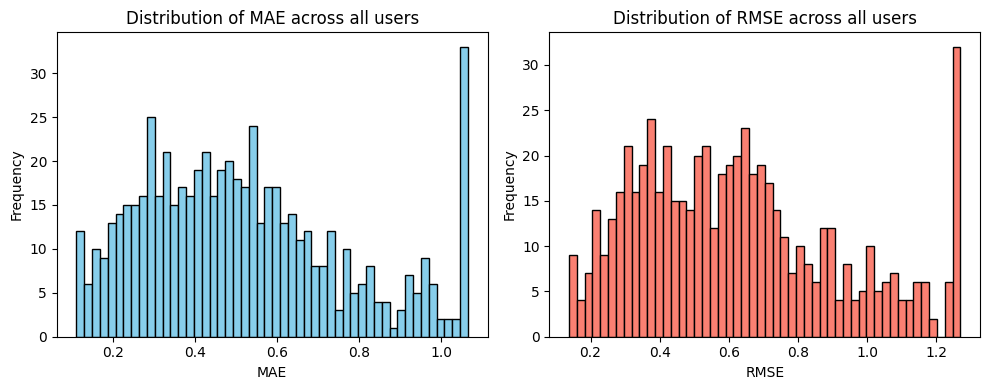

In [9]:
advanced_results_df = evaluate_all_users_advanced(
    ratings_matrix,
    n_hidden=5,
    random_state=42,
    plot=True,
    corr_threshold=0.1,
    use_negatives=True
)

## 4. Conclusion

In [10]:
def evaluate_improved_recommendations(ratings_matrix, user_id,
                                      n_hidden=5,
                                      random_state=42,
                                      plot=True,
                                      corr_threshold=0.1,
                                      use_negatives=True):
    """
    Single-user evaluation using the improved CF method:
    - mean-centering
    - correlation thresholding
    - handling negative correlations
    - squared weights
    """

    np.random.seed(random_state)
    target_ratings = ratings_matrix[user_id].copy()

    rated_movies = target_ratings.dropna().index
    if len(rated_movies) == 0:
        return None, None

    nh = min(n_hidden, len(rated_movies))
    hidden_movies = np.random.choice(rated_movies, size=nh, replace=False)
    hidden_ratings = target_ratings[hidden_movies].copy()

    ratings_matrix.loc[hidden_movies, user_id] = np.nan

    user_corr = ratings_matrix.corr()[user_id].drop(user_id)
    user_mean = ratings_matrix.mean()

    similarities = user_corr[user_corr.abs() >= corr_threshold]
    if similarities.empty:
        ratings_matrix.loc[hidden_movies, user_id] = target_ratings[hidden_movies]
        return None, None

    predicted_scores = {}

    for movie in ratings_matrix.index:

        users_who_rated = ratings_matrix.loc[movie].dropna().index
        relevant_users = users_who_rated.intersection(similarities.index)

        if len(relevant_users) < 2:
            continue

        weights = similarities[relevant_users]
        ratings = ratings_matrix.loc[movie, relevant_users] - user_mean[relevant_users]

        valid_mask = ratings.notna() & weights.notna()
        ratings = ratings[valid_mask]
        weights = weights[valid_mask]
        if len(weights) == 0:
            continue

        # Handle negative correlations
        if use_negatives:
            neg = weights < 0
            ratings[neg] = -ratings[neg]

        # Square weights
        weights = weights ** 2

        denom = np.sum(weights)
        if denom == 0:
            continue

        pred = user_mean[user_id] + np.sum(weights * ratings) / denom
        pred = np.clip(pred, 0.5, 5)

        predicted_scores[movie] = pred

    predicted_scores = pd.Series(predicted_scores)

    hidden_predicted = [m for m in hidden_movies if m in predicted_scores.index]
    if not hidden_predicted:
        ratings_matrix.loc[hidden_movies, user_id] = target_ratings[hidden_movies]
        return None, None

    predicted_hidden = predicted_scores[hidden_predicted]
    actual_hidden = hidden_ratings[hidden_predicted]

    mae = mean_absolute_error(actual_hidden, predicted_hidden)
    rmse = np.sqrt(mean_squared_error(actual_hidden, predicted_hidden))

    if plot:
        plt.figure(figsize=(6, 6))
        plt.scatter(actual_hidden, predicted_hidden, color='blue')
        plt.plot([0.5, 5], [0.5, 5], 'r--', label='Ideal (y=x)')
        plt.xlabel("Actual Ratings")
        plt.ylabel("Predicted Ratings")
        plt.title(f"Improved CF - User {user_id}")
        plt.xlim(0.5, 5)
        plt.ylim(0.5, 5)
        plt.grid(True)
        plt.legend()
        plt.show()
    ratings_matrix.loc[hidden_movies, user_id] = target_ratings[hidden_movies]

    return mae, rmse


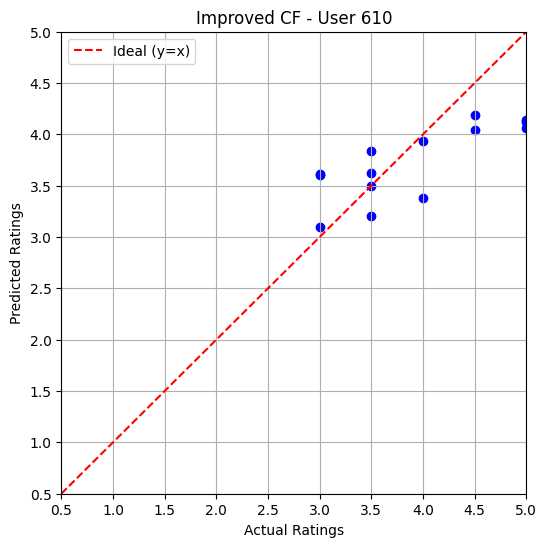

0.4431102492276943 0.5382782476000052


In [11]:
mae, rmse = evaluate_improved_recommendations(ratings_matrix,
                                              user_id=610,
                                              n_hidden=20,
                                              plot=True)

print(mae, rmse)

## Strengths

### **1. Mean-Centering Reduces User Bias**
Subtracting each user’s average rating makes the model compare users based on *taste patterns* instead of raw scores.  
- Helps when users always rate high or low.
- Improves correlation quality.
- Reduces systematic prediction errors.

### **2. Uses Both Positive and Negative Correlations**
Negative correlations are flipped (rating deviations are negated), letting the model learn from “opposite taste” users.  
- Strong improvement for sparse datasets.
- Recovers signal otherwise discarded in basic CF.

### **3. Thresholding Removes Noise**
Ignoring correlations with small magnitude prevents weak, noisy relationships from influencing predictions.

### **4. Squared Weights Emphasize Reliable Similarities**
Squaring correlations gives more power to strong relationships and suppresses weak ones, stabilizing predictions.

### **5. Better Overall Accuracy**
These changes lead to a large reduction in MAE/RMSE (0.53 vs. 0.88 MAE), demonstrating better modeling of user behavior.

---

## Weaknesses / Limitations

### **1. Users With One “Odd” Rating Can Mislead**
If a generally low-rating user suddenly gives one movie a very high score, mean-centering makes this look like a large positive deviation, which may heavily influence predictions despite having weak overall similarity.

### **2. Squaring Correlations Can Over-Amplify Few Users**
If only one or two users have high correlation, squaring may give them disproportionate control over the prediction.

### **3. Negative Correlation Handling Is Simplistic**
Simply negating deviations assumes a symmetric “opposite taste” relationship, which may not hold in practice (e.g., users might disagree only on certain genres).

### **4. Sensitive to Correlation Quality**
Pearson correlation is unstable when users have few overlapping rated movies, which can introduce noise even with thresholding.

### **5. Does Not Consider Movie Features**
Pure user–user CF fails when:
- Movies have few ratings,
- New movies are added,
- Users have very unique tastes.

Movie-based models or factorization methods solve these issues better.

---

## Overall
The improved method is clearly stronger: it eliminates bias, uses more information, and stabilizes predictions.  
But it can still be misled by outlier user behavior, brittle correlations, or sparse data, and it lacks movie-level modeling.

